In [ ]:
!pip install -q transformers peft bitsandbytes accelerate datasets sentencepiece triton

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00


In [ ]:
import torch
import pandas as pd
import numpy as np

from dataclasses import dataclass
from typing import Dict, List, Iterator
from sklearn.model_selection import KFold
from torch.utils.data import Dataset, DataLoader, Sampler

from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
)

from peft import LoraConfig, get_peft_model, TaskType

In [ ]:
@dataclass
class Config:
    model_name: str = "Helsinki-NLP/opus-mt-en-inc"
    source_lang: str = "bn"
    target_lang: str = "bn"

    max_length: int = 256
    batch_size: int = 2
    grad_accum: int = 8
    lr: float = 2e-4
    epochs: int = 3

    human_ratio: float = 0.20  # HARD constraint
    use_4bit: bool = True

    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05


In [ ]:
human_df = pd.read_csv("/content/human.csv")
synth_df = pd.read_csv("/content/synthetic.csv")

assert set(human_df.columns) == {"text", "gloss"}
assert set(synth_df.columns) == {"text", "gloss"}

print(f"Human: {len(human_df)} | Synthetic: {len(synth_df)}")

Human: 1000 | Synthetic: 4000


In [ ]:
class BanglaGlossDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        tokenizer: AutoTokenizer,
        max_length: int,
        src_lang: str,
        tgt_lang: str,
    ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]

        self.tokenizer.src_lang = self.src_lang
        model_inputs = self.tokenizer(
            row["text"],
            max_length=self.max_length,
            truncation=True,
        )

        with self.tokenizer.as_target_tokenizer():
            labels = self.tokenizer(
                row["gloss"],
                max_length=self.max_length,
                truncation=True,
            )

        model_inputs["labels"] = labels["input_ids"]
        return {k: torch.tensor(v) for k, v in model_inputs.items()}


In [ ]:
class MixedRatioSampler(Sampler[int]):
    def __init__(
        self,
        human_size: int,
        synth_size: int,
        human_ratio: float,
        epoch_size: int,
        seed: int = 42,
    ):
        self.human_size = human_size
        self.synth_size = synth_size
        self.human_ratio = human_ratio
        self.epoch_size = epoch_size
        self.rng = np.random.default_rng(seed)

    def __iter__(self) -> Iterator[int]:
        human_count = int(self.epoch_size * self.human_ratio)
        synth_count = self.epoch_size - human_count

        human_indices = self.rng.choice(
            self.human_size, size=human_count, replace=True
        )

        synth_indices = self.rng.choice(
            self.synth_size, size=synth_count, replace=False
        ) + self.human_size  # offset

        mixed = np.concatenate([human_indices, synth_indices])
        self.rng.shuffle(mixed)

        return iter(mixed.tolist())

    def __len__(self) -> int:
        return self.epoch_size

In [ ]:
cfg = Config()

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
tokenizer.src_lang = cfg.source_lang
tokenizer.tgt_lang = cfg.target_lang

human_ds = BanglaGlossDataset(
    human_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
)
synth_ds = BanglaGlossDataset(
    synth_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
)

full_df = pd.concat([human_df, synth_df], ignore_index=True)
full_ds = BanglaGlossDataset(
    full_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/969k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [ ]:
bnb_cfg = None
if cfg.use_4bit:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )

model = AutoModelForSeq2SeqLM.from_pretrained(
    cfg.model_name,
    quantization_config=bnb_cfg,
    device_map="auto",
)

lora_cfg = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["q_proj", "v_proj"],
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/305M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/305M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

trainable params: 589,824 || all params: 140,115,968 || trainable%: 0.4210


In [ ]:
combined_df = pd.concat(
    [human_df.assign(source="human"), synth_df.assign(source="synthetic")],
    ignore_index=True,
)

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

kf_splits = []
for train_index, val_index in kf.split(combined_df):
    kf_splits.append((train_index, val_index))

print(f"Combined DataFrame shape: {combined_df.shape}")
print(f"Number of K-Fold splits: {len(kf_splits)}")
print("First split train_index length:", len(kf_splits[0][0]))
print("First split val_index length:", len(kf_splits[0][1]))

Combined DataFrame shape: (5000, 3)
Number of K-Fold splits: 5
First split train_index length: 4000
First split val_index length: 1000


In [ ]:
class BanglaGlossDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        tokenizer: AutoTokenizer,
        max_length: int,
        src_lang: str,
        tgt_lang: str,
    ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]

        self.tokenizer.src_lang = self.src_lang
        model_inputs = self.tokenizer(
            row["text"],
            max_length=self.max_length,
            truncation=True,
        )

        # Removed with self.tokenizer.as_target_tokenizer():
        self.tokenizer.src_lang = self.tgt_lang # Set target language for label tokenization
        labels = self.tokenizer(
            row["gloss"],
            max_length=self.max_length,
            truncation=True,
        )
        self.tokenizer.src_lang = self.src_lang # Reset source language

        model_inputs["labels"] = labels["input_ids"]
        return {k: torch.tensor(v) for k, v in model_inputs.items()}

In [ ]:
combined_df = pd.concat(
    [human_df.assign(source="human"), synth_df.assign(source="synthetic")],
    ignore_index=True,
)

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

kf_splits = []
for train_index, val_index in kf.split(combined_df):
    kf_splits.append((train_index, val_index))

print(f"Combined DataFrame shape: {combined_df.shape}")
print(f"Number of K-Fold splits: {len(kf_splits)}")
print("First split train_index length:", len(kf_splits[0][0]))
print("First split val_index length:", len(kf_splits[0][1]))

Combined DataFrame shape: (5000, 3)
Number of K-Fold splits: 5
First split train_index length: 4000
First split val_index length: 1000


In [ ]:
all_fold_logs = []

for fold_idx, (train_index, val_index) in enumerate(kf_splits):
    print(f"\n--- Starting training for Fold {fold_idx + 1}/{len(kf_splits)} ---")

    # 4. Split combined_df into train_df and val_df
    train_df = combined_df.iloc[train_index].reset_index(drop=True)
    val_df = combined_df.iloc[val_index].reset_index(drop=True)

    # 5. Separate train_df into human_train_df and synth_train_df
    human_train_df = train_df[train_df['source'] == 'human'].reset_index(drop=True)
    synth_train_df = train_df[train_df['source'] == 'synthetic'].reset_index(drop=True)

    # 6. Re-initialize the model for the current fold
    current_bnb_cfg = None
    if cfg.use_4bit:
        current_bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
        )

    model = AutoModelForSeq2SeqLM.from_pretrained(
        cfg.model_name,
        quantization_config=current_bnb_cfg,
        device_map="auto",
    )

    # 7. Re-initialize the LoRA configuration
    current_lora_cfg = LoraConfig(
        r=cfg.lora_r,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM,
        target_modules=["q_proj", "v_proj"],
    )
    model = get_peft_model(model, current_lora_cfg)
    print(f"Fold {fold_idx + 1}: ")
    model.print_trainable_parameters()

    # 8. Create BanglaGlossDataset instances
    human_train_ds = BanglaGlossDataset(
        human_train_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )
    synth_train_ds = BanglaGlossDataset(
        synth_train_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )
    val_ds = BanglaGlossDataset(
        val_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )

    # 9. Concatenate human_train_df and synth_train_df to create full_train_df and then create full_train_ds
    full_train_df = pd.concat([human_train_df, synth_train_df], ignore_index=True)
    full_train_ds = BanglaGlossDataset(
        full_train_df, tokenizer, cfg.max_length, cfg.source_lang, cfg.target_lang
    )

    # 10. Initialize a MixedRatioSampler for the training set of the current fold
    # The epoch_size should be based on the synthetic data count in the training split
    current_epoch_size = len(synth_train_ds)
    current_sampler = MixedRatioSampler(
        human_size=len(human_train_ds),
        synth_size=len(synth_train_ds),
        human_ratio=cfg.human_ratio,
        epoch_size=current_epoch_size,
        seed=42 + fold_idx, # Use a different seed for each fold
    )

    # 11. Configure TrainingArguments
    current_training_args = TrainingArguments(
        output_dir=f"./marian-lora-fold-{fold_idx + 1}",
        per_device_train_batch_size=cfg.batch_size,
        gradient_accumulation_steps=cfg.grad_accum,
        learning_rate=cfg.lr,
        num_train_epochs=cfg.epochs,
        fp16=True,
        save_strategy="epoch",
        eval_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        remove_unused_columns=False,
        report_to="none",
    )

    # 12. Initialize DataCollatorForSeq2Seq
    current_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    # 13. Create a Trainer instance
    trainer = Trainer(
        model=model,
        args=current_training_args,
        train_dataset=full_train_ds, # Use full_train_ds for the Trainer initialization
        eval_dataset=val_ds,
        data_collator=current_data_collator,
    )

    # Override the get_train_dataloader method to use the custom sampler
    trainer.get_train_dataloader = lambda: DataLoader(
        full_train_ds,
        batch_size=cfg.batch_size,
        sampler=current_sampler,
        collate_fn=current_data_collator,
    )

    # 14. Train the model for the current fold
    trainer.train()

    # 15. Save the trained model and tokenizer for the current fold
    model.save_pretrained(f"./marian-lora-fold-{fold_idx + 1}")
    tokenizer.save_pretrained(f"./marian-lora-fold-{fold_idx + 1}")

    # 16. Append trainer.state.log_history to the all_fold_logs list
    all_fold_logs.append(trainer.state.log_history)

    print(f"--- Finished training for Fold {fold_idx + 1} ---")


--- Starting training for Fold 1/5 ---


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Fold 1: 
trainable params: 589,824 || all params: 140,115,968 || trainable%: 0.4210


/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Fold 5: 
trainable params: 589,824 || all params: 140,115,968 || trainable%: 0.4210


Epoch,Training Loss,Validation Loss
1,16.114147,1.539877
2,12.154344,1.178630
3,11.556917,1.098932


--- Finished training for Fold 5 ---


In [ ]:
!zip -r marian-lora-fold-1.zip /content/marian-lora-fold-1/
!zip -r marian-lora-fold-2.zip /content/marian-lora-fold-2/
!zip -r marian-lora-fold-3.zip /content/marian-lora-fold-3/
!zip -r marian-lora-fold-4.zip /content/marian-lora-fold-4/
!zip -r marian-lora-fold-5.zip /content/marian-lora-fold-5/

In [ ]:
from google.colab import files
files.download("marian-lora-fold-1.zip")
files.download("marian-lora-fold-2.zip")
files.download("marian-lora-fold-3.zip")
files.download("marian-lora-fold-4.zip")
files.download("marian-lora-fold-5.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
all_fold_losses = []

for fold_idx, fold_log_history in enumerate(all_fold_logs):
    train_loss_history = []
    eval_loss_history = []

    for log_entry in fold_log_history:
        if 'loss' in log_entry:
            train_loss_history.append({'step': log_entry['step'], 'loss': log_entry['loss']})
        if 'eval_loss' in log_entry:
            eval_loss_history.append({'step': log_entry['step'], 'eval_loss': log_entry['eval_loss']})

    all_fold_losses.append({
        'train_history': train_loss_history,
        'eval_history': eval_loss_history
    })

print(f"Number of folds processed: {len(all_fold_losses)}")
print("First fold's training history (first 2 entries):", all_fold_losses[0]['train_history'][:2])
print("First fold's evaluation history (first 2 entries):", all_fold_losses[0]['eval_history'][:2])

Number of folds processed: 5
First fold's training history (first 2 entries): [{'step': 50, 'loss': 38.75074951171875}, {'step': 100, 'loss': 22.05111572265625}]
First fold's evaluation history (first 2 entries): [{'step': 201, 'eval_loss': 1.5386970043182373}, {'step': 402, 'eval_loss': 1.1801915168762207}]


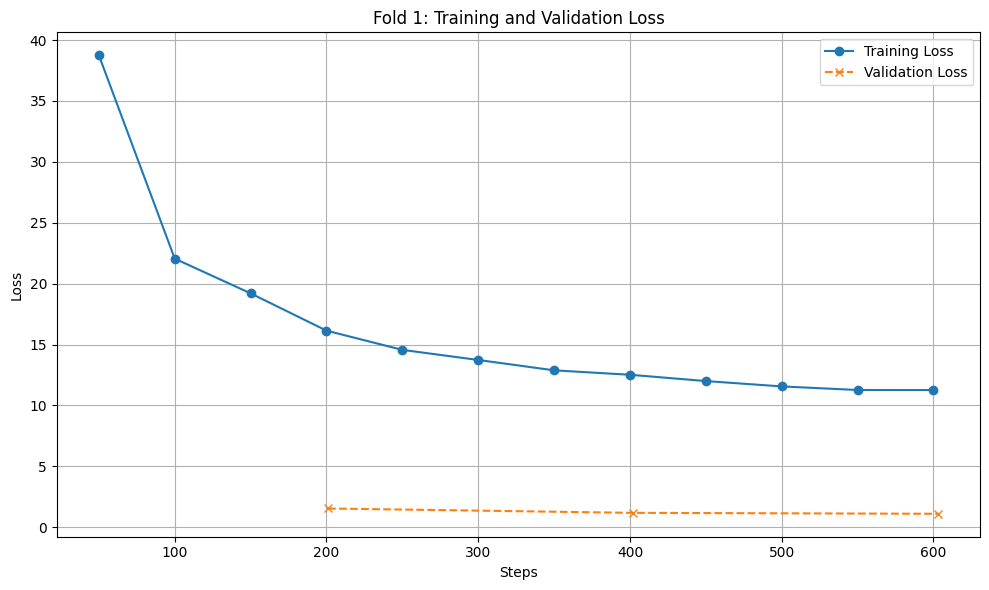

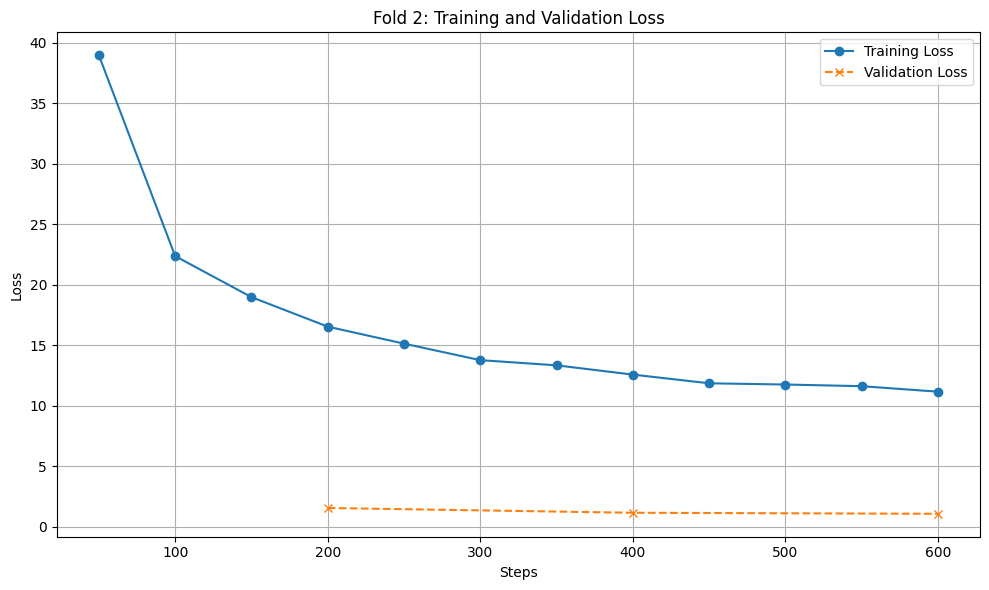

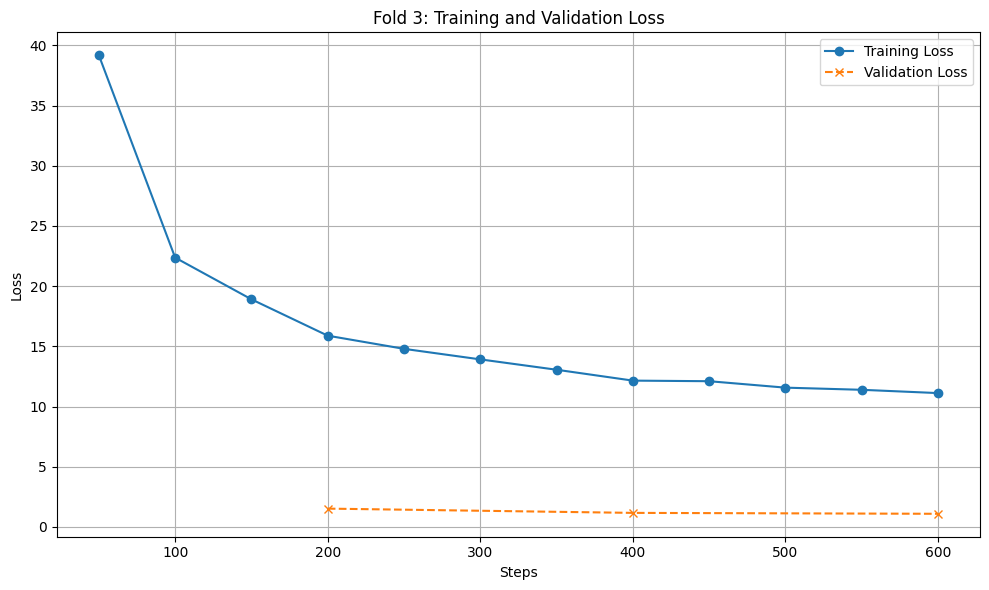

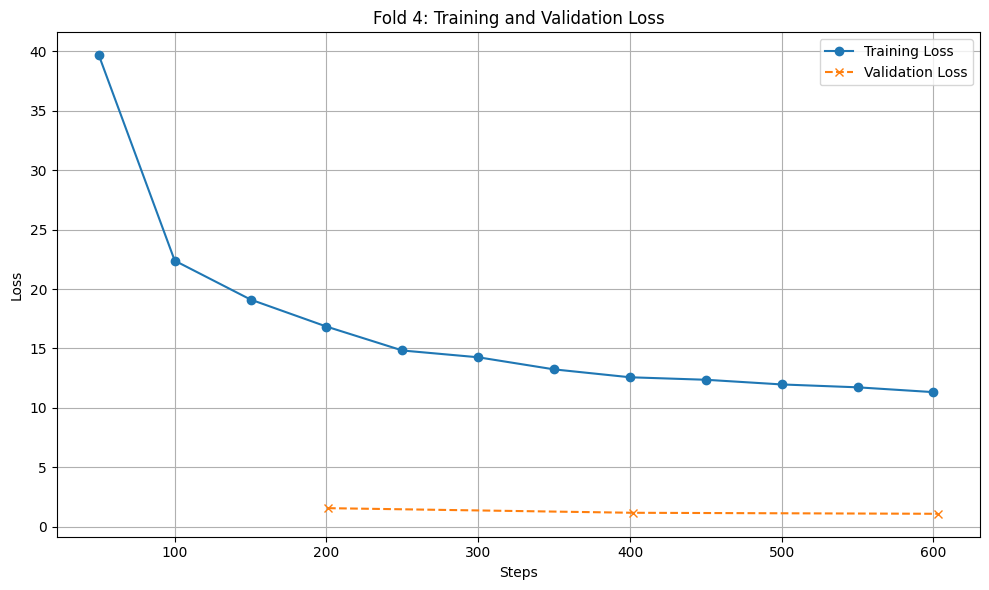

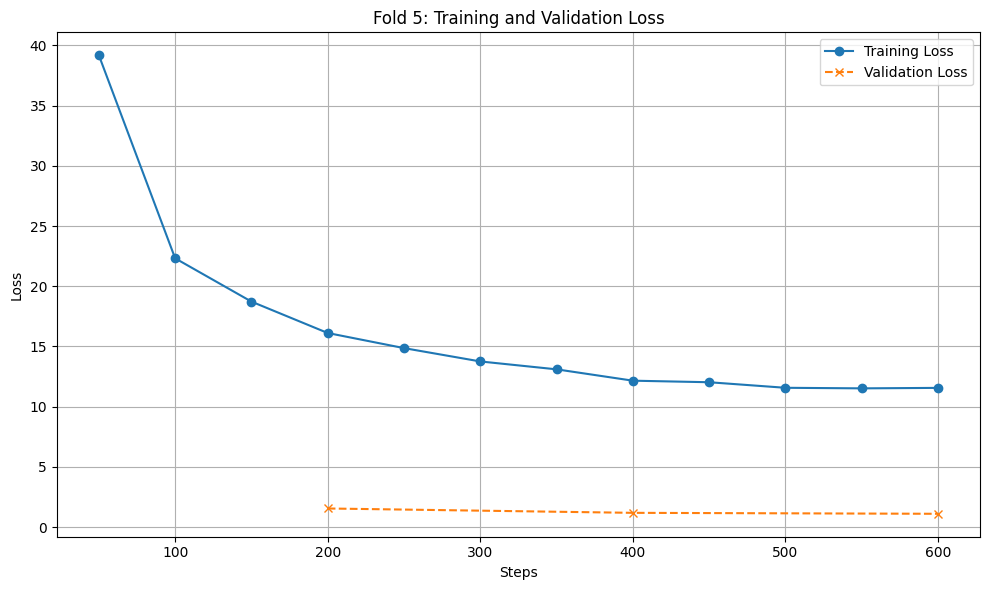

In [ ]:
import matplotlib.pyplot as plt

for fold_idx, fold_losses in enumerate(all_fold_losses):
    train_history = fold_losses['train_history']
    eval_history = fold_losses['eval_history']

    # Extract steps and losses for training
    train_steps = [entry['step'] for entry in train_history]
    train_loss = [entry['loss'] for entry in train_history]

    # Extract steps and losses for evaluation
    eval_steps = [entry['step'] for entry in eval_history]
    eval_loss = [entry['eval_loss'] for entry in eval_history]

    plt.figure(figsize=(10, 6))
    plt.plot(train_steps, train_loss, label='Training Loss', marker='o', linestyle='-')
    plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='x', linestyle='--')

    plt.title(f'Fold {fold_idx + 1}: Training and Validation Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
min_eval_losses = []
for fold_idx, fold_losses in enumerate(all_fold_losses):
    eval_history = fold_losses['eval_history']
    if eval_history:
        # Extract only the 'eval_loss' values
        current_fold_eval_losses = [entry['eval_loss'] for entry in eval_history]
        min_eval_loss_for_fold = min(current_fold_eval_losses)
        min_eval_losses.append({'fold_idx': fold_idx + 1, 'min_eval_loss': min_eval_loss_for_fold})
    else:
        min_eval_losses.append({'fold_idx': fold_idx + 1, 'min_eval_loss': float('inf')}) # Handle folds with no eval history

# Find the best performing fold
best_fold = min(min_eval_losses, key=lambda x: x['min_eval_loss'])

print("Minimum validation losses per fold:", min_eval_losses)
print("Best performing fold:", best_fold)

Minimum validation losses per fold: [{'fold_idx': 1, 'min_eval_loss': 1.10207200050354}, {'fold_idx': 2, 'min_eval_loss': 1.0890494585037231}, {'fold_idx': 3, 'min_eval_loss': 1.088590145111084}, {'fold_idx': 4, 'min_eval_loss': 1.091129183769226}, {'fold_idx': 5, 'min_eval_loss': 1.098931908607483}]
Best performing fold: {'fold_idx': 3, 'min_eval_loss': 1.088590145111084}
